# Plan de l'Aiguille (Chamonix-Mont-Blanc)

## Chargement des librairies

In [1]:
import os
import sys

# Ajout dans la variable PATH du système du chemin où est installée la librairie tracklib
module_path = os.path.abspath(os.path.join('../../../../tracklib'))
if module_path not in sys.path:
    sys.path.append(module_path)
# Alias pour tracklib
import tracklib as tkl

# Ajout dans la variable PATH du système du chemin où est installée la librairie footprint2graph
module_path = os.path.abspath(os.path.join('../../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

In [2]:
import matplotlib.pyplot as plt
import os
import time

from footprint2graph import footprint2grap
from footprint2graph import read_config

from footprint2graph.util.Outdoorvision import load_raw_tracks_split

## Chargement des paramètres

In [3]:
print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
print ('`````````````````````````````````````````````````````````````````````')
print ('  Generate a footprint graph                                         ')
print ('             from hiking trajectories                                ')
print ("             in the Plan de l'Aiguille, dans la vallée de Chamonix, summer 2024.  ")
print ('’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’')
print ('!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!')
print ('')


""" ======================================================================= """
"""     Load parameters                                                     """
"""                                                                         """

config_path = r'/home/md_vandamme/7_LIB/footprint2graph/data/config_plan_de_l_aiguille.yml'
config = read_config(config_path)


print('Paramètres relevés dans la configuration: ')
print ('Résultats enregistrés dans le répertoire: ', config['output']['RESULT_PATH'])

NBITER = int(config['graph_construction']['NUM_ITERATIONS'])
print ('Number of iterations: ', NBITER)

!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
`````````````````````````````````````````````````````````````````````
  Generate a footprint graph                                         
             from hiking trajectories                                
             in the Plan de l'Aiguille, dans la vallée de Chamonix, summer 2024.  
’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!

Paramètres relevés dans la configuration: 
Résultats enregistrés dans le répertoire:  /home/md_vandamme/4_RESEAU/ZTEMPZ3/
Number of iterations:  2


## Chargement des données

Les données proviennent de la plateforme Outdoorvision. Après avoir été formatées au format CSV, elles sont chargées dans une collection qui servira d’entrée au pipeline.

In [4]:
""" ======================================================================= """
"""     Chargement de la collection de traces                               """
"""                                                                         """

# chemin où sont stockés les traces Outdoorvision:
tracespathsource = r'/home/md_vandamme/5_GPS/OV/CHAM/walk/'

# Paramètre : Coordonnées de la zone d'étude sur laquelle on construit le réseau
#                           Polygone sous la forme d'un tableau de X et de Y
X = [1000852, 1001838, 1001852, 1000853, 1000852]
Y = [6541520,  6541524,  6540842,  6540839,  6541520]

fmt = tkl.TrackFormat({'ext': 'CSV',
                       'srid': 'ENU',
                       'id_E': 1, 'id_N': 0, 'id_U': 3, 'id_T': 2,
                       'time_fmt': '2D/2M/4Y 2h:2m:2s',
                       'separator': ';',
                       'header': 0,
                       'cmt': '#',
                       'read_all': True})
collection = load_raw_tracks_split(config['output']['RESULT_PATH'],
                                   tracespathsource, fmt, X, Y)

Loading and split outdoorvision track data...
Reading track data...
     Number files to load:  21211
Starting split ...
     500 / 21211
     1000 / 21211
     1500 / 21211
     2000 / 21211
     2500 / 21211
     3000 / 21211
     3500 / 21211
     4000 / 21211
     4500 / 21211
     5000 / 21211
     5500 / 21211
     6000 / 21211
     6500 / 21211
     7000 / 21211
     7500 / 21211
     8000 / 21211
     8500 / 21211
     9000 / 21211
     9500 / 21211
     10000 / 21211
     10500 / 21211
     11000 / 21211
     11500 / 21211
     12000 / 21211
     12500 / 21211
     13000 / 21211
     13500 / 21211
     14000 / 21211
     14500 / 21211
     15000 / 21211
     15500 / 21211
     16000 / 21211
     16500 / 21211
     17000 / 21211
     17500 / 21211
     18000 / 21211
     18500 / 21211
     19000 / 21211
     19500 / 21211
     20000 / 21211
     20500 / 21211
     21000 / 21211
     Number of tracks after split: 631


## Lancement du pipeline

In [5]:
# 
footprint2grap(config, collection, 'ERROR')

-----------------------------------------------------------------
-----------------------------------------------------------------
              ITERATION  1
-----------------------------------------------------------------
-----------------------------------------------------------------
Starting segmentation and resampling...
Starting segmentation ...
     500 / 631
    Number of tracks after segmentation: 688
Finished saving segmented tracks.
Starting resampling ...
    Number of tracks to resample:  688
    Number of tracks after resampling: 688
    Number of tracks after resampling: 688
Finished saving resampled tracks.
Stage 1 finished: segmentation and resampling.
Starting rasterization and vectorization (iteration 1) 

    Loading tracks from :  resample_grid
    Number of tracks to load:  688
    Building high-resolution geometry density grid G1 :  2 m ...
    Building low-resolution contextual density grid G2 :  30 m ...
    Assigning track points to the G1 and G2 grids
    

100% (341 of 341) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (846 of 846) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (403 of 403) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (663 of 663) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
  0% (0 of 1273) |                       | Elapsed Time: 0:00:00 ETA:  --:--:--

    Execution time (seconds): 0.4874405860900879
    Road surface smoothing completed.
    Starting centerline computation ...


100% (1273 of 1273) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (621 of 621) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (618 of 618) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (2711 of 2711) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (1113 of 1113) |####################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (967 of 967) |######################| Elapsed Time: 0:00:00 Time:  0:00:00
100% (963 of 963) |######################| Elapsed Time: 0:00:00 Time:  0:00:00


    Execution time (seconds): 0.7866277694702148
    Centerline computed.
Stage 2 completed: rasterization and vectorization.
Starting topology creation for the network
    Number of edges in the skeleton: 1669
    Finished loaded skeleton.
    /home/md_vandamme/4_RESEAU/ZTEMPZ3/network/tmp_in.csv not exists
    /home/md_vandamme/4_RESEAU/ZTEMPZ3/network/tmp_out.csv not exists


...

    Finished simplification of the skeleton.
Building [100 x 87] spatial index...
    Number of edges in the skeleton (after snapping): 81
    Edge count difference after snapping :  0
    Number of edges in the simplified skeleton: 73
    Number of nodes: 89
     Shortest edges limit :  50
    Number of edges in the skeleton (after removing the shortest edges): 2
    Conflation cannot be performed for node  68 ; the three incident edges are too long: 15 42 39
    Conflation cannot be performed for node  70 ; the three incident edges are too long: 24 37 39
    Conflation cannot be performed for node  72 ; the three incident edges are too long: 24 14 30
    Conflation cannot be performed for node  73 ; the three incident edges are too long: 14 37 52
    Conflation cannot be performed for node  86 ; the three incident edges are too long: 20 188 188
    Conflation cannot be performed for node  82 ; the three incident edges are too long: 20 80 46
    Conflation cannot be performed for node

100% (45 of 45) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


        Number of tracks: 1293
        Execution time (seconds): 2.009505033493042
    Starting map-matching ...
        Index spatial :  [100 x 87] spatial index centered on [1001241.8737958325; 6541182.067823667]
Map-matching preparation...
        Parameter search_radius:  25
        Map-matching ended.
        Execution time (seconds): 18.399590969085693
        Prepare map-matching results for candidate segment generation
    Number of map-matched points = 95981 (65.51 %)
    Map-matching results restructuring completed.
        Map-matching results exported.
Starting construction of candidate trajectory segments for each topology edge ...
    18  candidates for edge 23
    64  candidates for edge 89
    36  candidates for edge 54
    10  candidates for edge 56
    17  candidates for edge 98
    66  candidates for edge 55
    4  candidates for edge 60
    66  candidates for edge 81
    3  candidates for edge 34
    0  candidates for edge 95
    25  candidates for edge 108
    7  c

100% (40 of 40) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


Size of collection In  :  12
Size of collection In+1:  28
Size of collection In+In+1:  40
Building [100 x 74] spatial index...
Size of collection In+In+1 avec intersection:  41
Size of collection In+In+1 avec intersection et raccordement:  55
Nombre de géométries :  55
Size of reseau de mobilité:  55
End building the mobility network.
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
`````````````````````````````````````````````````````````````````````
                           FIN                                       
’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’’
!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!


## Visualisation du réseau de mobilité pédestre final

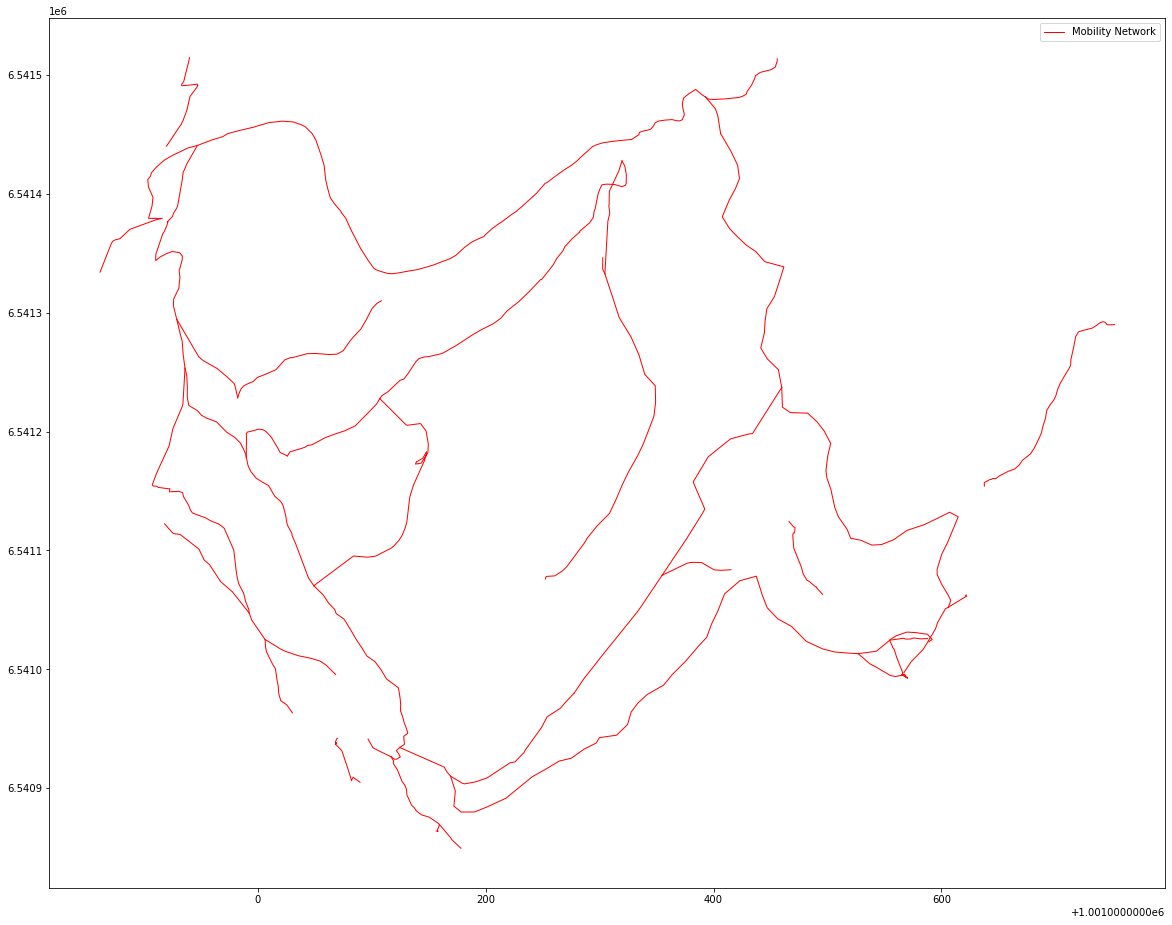

In [6]:
from footprint2graph.util.PlotRes import plotResultatFinal

plotResultatFinal(config['output']['RESULT_PATH'], '2')